In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("fhvhv_tripdata_2025-07.parquet")
df.head(5)

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2025-07-01 00:05:56,2025-07-01 00:08:03,2025-07-01 00:08:44,2025-07-01 00:28:42,65,179,9.930,...,0.00,0.0,0.0,26.11,N,N,N,N,N,0.0
1,HV0005,B03406,None,2025-07-01 00:09:38,2025-07-01 00:16:28,2025-07-01 00:17:28,2025-07-01 00:22:50,35,35,0.792,...,0.00,0.0,0.0,4.39,N,N,N,N,N,0.0
2,HV0003,B03404,B03404,2025-07-01 00:47:47,2025-07-01 00:51:20,2025-07-01 00:51:20,2025-07-01 01:04:56,233,143,3.050,...,2.75,0.0,0.0,12.53,N,N,N,N,N,1.5
3,HV0005,B03406,None,2025-07-01 00:05:36,2025-07-01 00:08:46,2025-07-01 00:09:18,2025-07-01 00:28:44,68,145,3.990,...,2.75,0.0,0.0,19.06,N,N,N,N,Y,1.5
4,HV0005,B03406,None,2025-07-01 00:10:04,2025-07-01 00:35:56,2025-07-01 00:35:58,2025-07-01 01:09:06,132,90,17.702,...,2.75,2.5,0.0,45.22,N,N,N,N,N,1.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19653012 entries, 0 to 19653011
Data columns (total 25 columns):
 #   Column                Dtype         
---  ------                -----         
 0   hvfhs_license_num     object        
 1   dispatching_base_num  object        
 2   originating_base_num  object        
 3   request_datetime      datetime64[us]
 4   on_scene_datetime     datetime64[us]
 5   pickup_datetime       datetime64[us]
 6   dropoff_datetime      datetime64[us]
 7   PULocationID          int32         
 8   DOLocationID          int32         
 9   trip_miles            float64       
 10  trip_time             int64         
 11  base_passenger_fare   float64       
 12  tolls                 float64       
 13  bcf                   float64       
 14  sales_tax             float64       
 15  congestion_surcharge  float64       
 16  airport_fee           float64       
 17  tips                  float64       
 18  driver_pay            float64       
 19

In [4]:
pd.set_option("display.float_format", "{:.2f}".format)
df.describe()

,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,cbd_congestion_fee
count,19653012,19653012,19653012,19653012,19653012.00,19653012.00,19653012.00,19653012.00,19653012.00,19653012.00,19653012.00,19653012.00,19653012.00,19653012.00,19653012.00,19653012.00,19653012.00
mean,2025-07-16 20:39:32.614588,2025-07-16 20:43:12.156340,2025-07-16 20:44:06.626496,2025-07-16 21:03:54.842604,137.78,141.94,5.11,1188.20,26.57,1.10,0.67,2.21,0.95,0.22,1.17,20.73,0.51
min,2025-06-30 23:17:00,2025-06-30 22:30:16,2025-07-01 00:00:00,2025-07-01 00:02:29,2.00,1.00,0.00,1.00,-35.91,0.00,0.00,0.00,0.00,0.00,0.00,-35.38,0.00
25%,2025-07-09 11:30:18,2025-07-09 11:33:02.750000,2025-07-09 11:34:01,2025-07-09 11:54:46,75.00,75.00,1.57,596.00,12.17,0.00,0.29,1.00,0.00,0.00,0.00,9.10,0.00
50%,2025-07-16 22:54:34,2025-07-16 22:58:39,2025-07-16 22:59:29,2025-07-16 23:18:23,138.00,140.00,3.06,967.00,18.98,0.00,0.47,1.60,0.00,0.00,0.00,15.42,0.00
75%,2025-07-24 16:39:57,2025-07-24 16:43:16,2025-07-24 16:44:12,2025-07-24 17:09:47,207.00,216.00,6.43,1526.00,31.62,0.00,0.79,2.70,2.75,0.00,0.00,26.14,1.50
max,2025-08-01 00:03:23,2025-07-31 23:59:56,2025-07-31 23:59:59,2025-08-01 04:14:23,265.00,265.00,450.59,35554.00,2215.64,80.20,55.39,126.11,5.50,7.50,250.39,1579.08,3.00
std,NaN,NaN,NaN,NaN,74.68,77.99,6.02,858.32,24.87,3.59,0.65,2.04,1.30,0.72,3.56,18.46,0.71


In [5]:
# Map licence number with actual provider name
mapping = {
    "HV0002": "Juno",
    "HV0003": "Uber",
    "HV0004": "Via",
    "HV0005": "Lyft"
}

df["hvfhs_license_num"] = df["hvfhs_license_num"].replace(mapping)
df = df.rename(columns={
    "hvfhs_license_num": "Providers",
})

# Drop redundant columns
df.drop(["dispatching_base_num","originating_base_num"], axis = 1).head(5)

,Providers,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,Uber,2025-07-01 00:05:56,2025-07-01 00:08:03,2025-07-01 00:08:44,2025-07-01 00:28:42,65,179,9.93,1198,26.22,...,0.00,0.00,0.00,26.11,N,N,N,N,N,0.00
1,Lyft,2025-07-01 00:09:38,2025-07-01 00:16:28,2025-07-01 00:17:28,2025-07-01 00:22:50,35,35,0.79,322,6.27,...,0.00,0.00,0.00,4.39,N,N,N,N,N,0.00
2,Uber,2025-07-01 00:47:47,2025-07-01 00:51:20,2025-07-01 00:51:20,2025-07-01 01:04:56,233,143,3.05,816,21.76,...,2.75,0.00,0.00,12.53,N,N,N,N,N,1.50
3,Lyft,2025-07-01 00:05:36,2025-07-01 00:08:46,2025-07-01 00:09:18,2025-07-01 00:28:44,68,145,3.99,1166,23.03,...,2.75,0.00,0.00,19.06,N,N,N,N,Y,1.50
4,Lyft,2025-07-01 00:10:04,2025-07-01 00:35:56,2025-07-01 00:35:58,2025-07-01 01:09:06,132,90,17.70,1988,51.93,...,2.75,2.50,0.00,45.22,N,N,N,N,N,1.50


In [6]:
# Add column with total fare
df["total_fare"] = (
    df["base_passenger_fare"]
    + df["tolls"]
    + df["bcf"]
    + df["sales_tax"]
    + df["congestion_surcharge"]
    + df["airport_fee"]
    + df["tips"]
    + df["cbd_congestion_fee"]
)

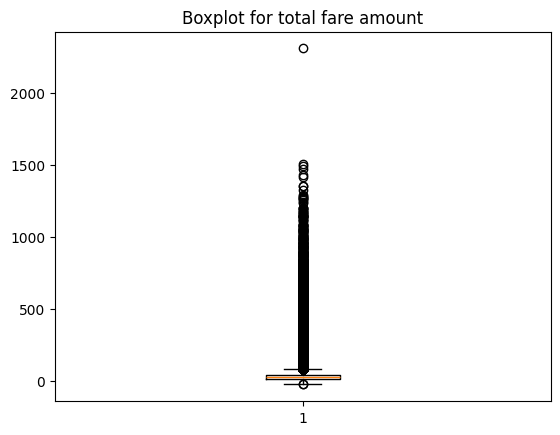

In [7]:
plt.boxplot(df["total_fare"])
plt.title("Boxplot for total fare amount")
plt.show()

In [8]:
Q1 = df["total_fare"].quantile(0.25)
Q3 = df["total_fare"].quantile(0.75)
IQR = Q3 - Q1
upper_whisker = Q3 + 1.5 * IQR
print(f"Total amount of upper outliers: {int((df["total_fare"] > upper_whisker).sum()):,}")

Total amount of upper outliers: 1,429,879


In [9]:
print(f"Fares over 300$: {(df["total_fare"] > 300).sum():,}")

Fares over 300$: 14,937


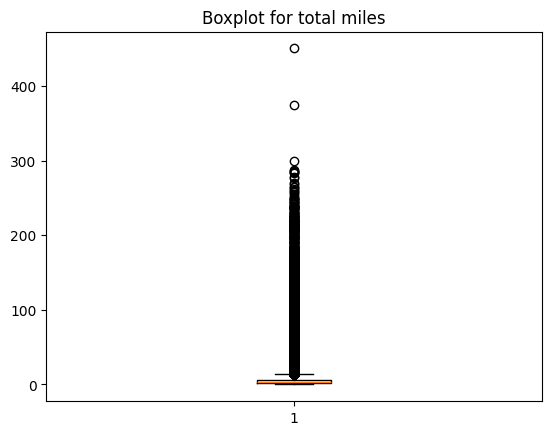

In [10]:
plt.boxplot(df["trip_miles"])
plt.title("Boxplot for total miles")
plt.show()

In [11]:
Q1 = df["trip_miles"].quantile(0.25)
Q3 = df["trip_miles"].quantile(0.75)
IQR = Q3 - Q1
upper_whisker = Q3 + 1.5 * IQR
print(f"Total amount of upper outliers: {int((df["trip_miles"] > upper_whisker).sum()):,}")

Total amount of upper outliers: 1,436,037


In [12]:
print(f"Trips with over 100 miles: {(df["trip_miles"] > 100).sum():,}")

Trips with over 100 miles: 2,607


In [13]:
df = df[df["total_fare"] <= 300]
df = df[df["trip_miles"] <= 100]
df = df[df['base_passenger_fare'] > 0]
df = df[df['driver_pay'] > 0]

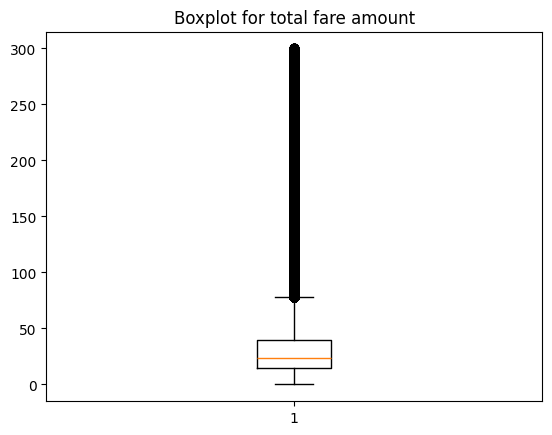

In [14]:
plt.boxplot(df["total_fare"])
plt.title("Boxplot for total fare amount")
plt.show()

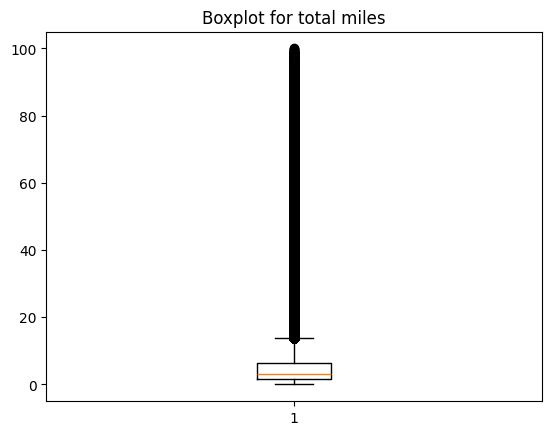

In [15]:
plt.boxplot(df["trip_miles"])
plt.title("Boxplot for total miles")
plt.show()